# Обучение модели спроса и выручки такси с погодой

Используем **один готовый parquet-файл**:

```text
data/processed/my_clean_3_with_weather.parquet
```

CSV-файлы с погодой больше не читаем и не объединяем через `merge`.

Модель будет прогнозировать:

- `demand` — сколько поездок будет в районе за час;
- `revenue` — какая будет суммарная выручка в районе за час.

In [39]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import matplotlib.pyplot as plt

## 1. Пути проекта



In [40]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "my_clean_3_with_weather.parquet"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("Файл существует:", DATA_PATH.exists())

PROJECT_ROOT: c:\Users\anast\Desktop\nyc_taxi_project
DATA_PATH: c:\Users\anast\Desktop\nyc_taxi_project\data\processed\my_clean_3_with_weather.parquet
Файл существует: True


## 2. Загружаем датасет



In [41]:
MAX_ROWS = None

if MAX_ROWS is None:
    taxi = pd.read_parquet(DATA_PATH)
else:
    taxi = pd.read_parquet(DATA_PATH).head(MAX_ROWS)

print("Размер исходной таблицы:", taxi.shape)
display(taxi.head())

print("Колонки:")
print(list(taxi.columns))

Размер исходной таблицы: (7494343, 36)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,cap_was_applied,PU_lon,PU_lat,DO_lon,DO_lat,trip_duration_min,temperature,precipitation,snowfall,weather_code
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1,1.17,1,N,262,74,2,...,False,-73.946510,40.775932,-73.937346,40.801169,4.683333,9.6,0.0,0.0,3
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1,0.90,1,N,229,237,2,...,False,-73.965146,40.756729,-73.965635,40.768615,5.383333,4.2,0.0,0.0,3
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1,0.95,1,N,45,261,1,...,False,-73.998151,40.712459,-74.013023,40.709139,7.016667,3.1,0.0,0.0,3
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5,0.88,1,N,237,141,1,...,False,-73.965635,40.768615,-73.959635,40.766948,19.250000,2.9,0.6,0.0,53
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2,1.03,1,N,229,140,1,...,False,-73.965146,40.756729,-73.954739,40.765484,3.666667,5.0,0.0,0.0,1


Колонки:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'source_file', 'sample_year', 'sample_month', 'month_total_rows', 'month_sample_rows', 'target_sample_frac', 'actual_sample_frac', 'cap_was_applied', 'PU_lon', 'PU_lat', 'DO_lon', 'DO_lat', 'trip_duration_min', 'temperature', 'precipitation', 'snowfall', 'weather_code']


## 3. Оставляем только поездки за 2023 и 2024 годы


In [42]:
taxi = taxi.copy()

required_columns = ["tpep_pickup_datetime", "PULocationID", "total_amount"]
missing_columns = [col for col in required_columns if col not in taxi.columns]

if missing_columns:
    raise ValueError(f"В датасете нет нужных колонок: {missing_columns}")

taxi["tpep_pickup_datetime"] = pd.to_datetime(
    taxi["tpep_pickup_datetime"],
    errors="coerce"
)

taxi["date_hour"] = taxi["tpep_pickup_datetime"].dt.floor("h")

taxi = taxi.dropna(subset=["date_hour"]).copy()

start_date = pd.Timestamp("2023-01-01 00:00:00")
end_date = pd.Timestamp("2025-01-01 00:00:00")

taxi = taxi[
    (taxi["date_hour"] >= start_date) &
    (taxi["date_hour"] < end_date)
].copy()

taxi = taxi.dropna(subset=["PULocationID", "total_amount"]).copy()
taxi["PULocationID"] = taxi["PULocationID"].astype(int)

# Убираем отрицательную выручку, чтобы модель не училась на странных возвратах/ошибках.
taxi = taxi[taxi["total_amount"] >= 0].copy()

print("Размер после фильтрации:", taxi.shape)
print("Минимальная дата поездок:", taxi["date_hour"].min())
print("Максимальная дата поездок:", taxi["date_hour"].max())

display(taxi.head())

Размер после фильтрации: (7494343, 37)
Минимальная дата поездок: 2023-01-01 00:00:00
Максимальная дата поездок: 2024-12-31 23:00:00


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,PU_lon,PU_lat,DO_lon,DO_lat,trip_duration_min,temperature,precipitation,snowfall,weather_code,date_hour
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1,1.17,1,N,262,74,2,...,-73.946510,40.775932,-73.937346,40.801169,4.683333,9.6,0.0,0.0,3,2023-01-29 17:00:00
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1,0.90,1,N,229,237,2,...,-73.965146,40.756729,-73.965635,40.768615,5.383333,4.2,0.0,0.0,3,2023-01-08 15:00:00
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1,0.95,1,N,45,261,1,...,-73.998151,40.712459,-74.013023,40.709139,7.016667,3.1,0.0,0.0,3,2023-01-21 19:00:00
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5,0.88,1,N,237,141,1,...,-73.965635,40.768615,-73.959635,40.766948,19.250000,2.9,0.6,0.0,53,2023-01-23 16:00:00
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2,1.03,1,N,229,140,1,...,-73.965146,40.756729,-73.954739,40.765484,3.666667,5.0,0.0,0.0,1,2023-01-26 21:00:00


## 4. Автоматически находим погодные признаки

Так как погода уже внутри parquet-файла, ищем погодные числовые колонки прямо в `taxi`.

In [43]:
weather_keywords = [
    "temperature",
    "temp",
    "humidity",
    "precipitation",
    "rain",
    "snow",
    "snowfall",
    "wind",
    "cloud",
    "pressure",
    "weather",
    "visibility",
    "dew",
]

numeric_columns = taxi.select_dtypes(include=[np.number]).columns.tolist()

not_weather_columns = {
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
}

weather_features = []

for col in numeric_columns:
    col_lower = col.lower()
    if col in not_weather_columns:
        continue
    if any(keyword in col_lower for keyword in weather_keywords):
        weather_features.append(col)

print("Найденные погодные признаки:")
print(weather_features)

Найденные погодные признаки:
['temperature', 'precipitation', 'snowfall', 'weather_code']


## 6. Агрегируем поездки по часу и району

Одна строка после группировки:

```text
date_hour + PULocationID
```

Для неё считаем:

- `demand` — количество поездок;
- `revenue` — сумма `total_amount`;
- погода — среднее значение погодных колонок.

In [45]:
agg_dict = {
    "demand": ("PULocationID", "size"),
    "revenue": ("total_amount", "sum"),
}

for col in weather_features:
    agg_dict[col] = (col, "mean")

hourly = (
    taxi
    .groupby(["date_hour", "PULocationID"])
    .agg(**agg_dict)
    .reset_index()
)

print("Размер агрегированной таблицы:", hourly.shape)
display(hourly.head())

print("Минимальный час:", hourly["date_hour"].min())
print("Максимальный час:", hourly["date_hour"].max())

Размер агрегированной таблицы: (950661, 8)


,date_hour,PULocationID,demand,revenue,temperature,precipitation,snowfall,weather_code
0,2023-01-01,4,4,139.70,10.9,1.0,0.0,55.0
1,2023-01-01,13,2,40.84,10.9,1.0,0.0,55.0
2,2023-01-01,41,2,20.10,10.9,1.0,0.0,55.0
3,2023-01-01,43,13,327.27,10.9,1.0,0.0,55.0
4,2023-01-01,48,6,153.43,10.9,1.0,0.0,55.0


Минимальный час: 2023-01-01 00:00:00
Максимальный час: 2024-12-31 23:00:00


## 7. Признаки из даты

In [46]:
hourly = hourly.copy()

hourly["month"] = hourly["date_hour"].dt.month
hourly["day"] = hourly["date_hour"].dt.day
hourly["hour"] = hourly["date_hour"].dt.hour
hourly["dayofweek"] = hourly["date_hour"].dt.dayofweek
hourly["is_weekend"] = (hourly["dayofweek"] >= 5).astype(int)



display(hourly.head())

,date_hour,PULocationID,demand,revenue,temperature,precipitation,snowfall,weather_code,month,day,hour,dayofweek,is_weekend
0,2023-01-01,4,4,139.70,10.9,1.0,0.0,55.0,1,1,0,6,1
1,2023-01-01,13,2,40.84,10.9,1.0,0.0,55.0,1,1,0,6,1
2,2023-01-01,41,2,20.10,10.9,1.0,0.0,55.0,1,1,0,6,1
3,2023-01-01,43,13,327.27,10.9,1.0,0.0,55.0,1,1,0,6,1
4,2023-01-01,48,6,153.43,10.9,1.0,0.0,55.0,1,1,0,6,1


## 8. Добавляем лаги

Лаги — это данные из прошлого для этого же района:

- `lag_1_demand` — спрос час назад;
- `lag_24_demand` — спрос сутки назад;
- `lag_1_revenue` — выручка час назад;
- `lag_24_revenue` — выручка сутки назад.

In [47]:
hourly = hourly.sort_values(["PULocationID", "date_hour"]).copy()

hourly["lag_1_demand"] = hourly.groupby("PULocationID")["demand"].shift(1)
hourly["lag_24_demand"] = hourly.groupby("PULocationID")["demand"].shift(24)

hourly["lag_1_revenue"] = hourly.groupby("PULocationID")["revenue"].shift(1)
hourly["lag_24_revenue"] = hourly.groupby("PULocationID")["revenue"].shift(24)

lag_columns = [
    "lag_1_demand",
    "lag_24_demand",
    "lag_1_revenue",
    "lag_24_revenue",
]

hourly[lag_columns] = hourly[lag_columns].fillna(0)

display(hourly.head())

,date_hour,PULocationID,demand,revenue,temperature,precipitation,snowfall,weather_code,month,day,hour,dayofweek,is_weekend,lag_1_demand,lag_24_demand,lag_1_revenue,lag_24_revenue
2608,2023-01-03 08:00:00,1,1,351.0,6.3,0.0,0.0,3.0,1,3,8,1,0,0.0,0.0,0.0,0.0
7830,2023-01-07 15:00:00,1,1,152.0,8.2,0.0,0.0,3.0,1,7,15,5,1,1.0,0.0,351.0,0.0
18610,2023-01-16 15:00:00,1,1,91.0,7.9,0.0,0.0,0.0,1,16,15,0,0,1.0,0.0,152.0,0.0
39965,2023-02-03 13:00:00,1,1,140.4,-4.4,0.0,0.0,0.0,2,3,13,4,0,1.0,0.0,91.0,0.0
44568,2023-02-07 10:00:00,1,1,31.0,-1.6,0.0,0.0,3.0,2,7,10,1,0,1.0,0.0,140.4,0.0


## 9. Делим данные на train/test по времени

Правильно для прогноза будущего:

```text
первые 80% часов  -> train
последние 20% часов -> test
```

Случайно перемешивать нельзя, потому что тогда модель увидит кусочки будущего.

In [48]:
unique_hours = np.array(sorted(hourly["date_hour"].unique()))

split_index = int(len(unique_hours) * 0.8)
split_time = unique_hours[split_index]

train = hourly[hourly["date_hour"] < split_time].copy()
test = hourly[hourly["date_hour"] >= split_time].copy()

print("Граница разделения:", split_time)
print("Train:", train.shape)
print("Test:", test.shape)

print("Train даты:", train["date_hour"].min(), "—", train["date_hour"].max())
print("Test даты:", test["date_hour"].min(), "—", test["date_hour"].max())

train.to_parquet(TABLES_DIR / "train_hourly_with_weather.parquet", index=False)
test.to_parquet(TABLES_DIR / "test_hourly_with_weather.parquet", index=False)

print("Train/test сохранены в:", TABLES_DIR)

Граница разделения: 2024-08-07 20:00:00
Train: (743187, 17)
Test: (207474, 17)
Train даты: 2023-01-01 00:00:00 — 2024-08-07 19:00:00
Test даты: 2024-08-07 20:00:00 — 2024-12-31 23:00:00
Train/test сохранены в: c:\Users\anast\Desktop\nyc_taxi_project\reports\tables


## 10. Готовим признаки и целевые переменные

In [49]:
base_features = [
    "PULocationID",
    "month",
    "day",
    "hour",
    "dayofweek",
    "is_weekend",
    "lag_1_demand",
    "lag_24_demand",
    "lag_1_revenue",
    "lag_24_revenue",
]

features = base_features + weather_features
features = [col for col in features if col in hourly.columns]

print("Признаки модели:")
print(features)

X_train = train[features].copy()
X_test = test[features].copy()

y_train_demand = train["demand"].copy()
y_test_demand = test["demand"].copy()

y_train_revenue = train["revenue"].copy()
y_test_revenue = test["revenue"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Признаки модели:
['PULocationID', 'month', 'day', 'hour', 'dayofweek', 'is_weekend', 'lag_1_demand', 'lag_24_demand', 'lag_1_revenue', 'lag_24_revenue', 'temperature', 'precipitation', 'snowfall', 'weather_code']
X_train: (743187, 14)
X_test: (207474, 14)


## 11. Обучаем две модели

Одна модель для спроса, вторая для выручки.

In [50]:
demand_model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.05,
    max_leaf_nodes=63,
    l2_regularization=0.01,
    random_state=42
)

revenue_model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.05,
    max_leaf_nodes=63,
    l2_regularization=0.01,
    random_state=42
)

print("Обучаем модель спроса...")
demand_model.fit(X_train, y_train_demand)

print("Обучаем модель выручки...")
revenue_model.fit(X_train, y_train_revenue)

print("Готово")

Обучаем модель спроса...
Обучаем модель выручки...
Готово


## 12. Оцениваем качество

In [51]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики для {name}:")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}")
    print()

    return {
        "target": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

test_pred_demand = demand_model.predict(X_test)
test_pred_revenue = revenue_model.predict(X_test)

test_pred_demand = np.maximum(test_pred_demand, 0)
test_pred_revenue = np.maximum(test_pred_revenue, 0)

metrics = [
    evaluate_model(y_test_demand, test_pred_demand, "demand"),
    evaluate_model(y_test_revenue, test_pred_revenue, "revenue"),
]

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

metrics_df.to_csv(TABLES_DIR / "model_metrics_with_weather.csv", index=False)

Метрики для demand:
MAE:  2.188
RMSE: 3.537
R2:   0.858

Метрики для revenue:
MAE:  74.004
RMSE: 748.260
R2:   0.182



,target,MAE,RMSE,R2
0,demand,2.188352,3.536712,0.857824
1,revenue,74.004134,748.259530,0.181938


## 13. Сохраняем модели

In [52]:
joblib.dump(demand_model, MODELS_DIR / "demand_model_with_weather.joblib")
joblib.dump(revenue_model, MODELS_DIR / "revenue_model_with_weather.joblib")
joblib.dump(features, MODELS_DIR / "model_features_with_weather.joblib")

print("Модели сохранены в:", MODELS_DIR)

Модели сохранены в: c:\Users\anast\Desktop\nyc_taxi_project\models


## 14. Сохраняем предсказания на тесте

In [53]:
test_predictions = test[["date_hour", "PULocationID", "demand", "revenue"]].copy()

test_predictions["predicted_demand"] = test_pred_demand
test_predictions["predicted_revenue"] = test_pred_revenue

test_predictions.to_csv(TABLES_DIR / "test_predictions_with_weather.csv", index=False)

display(test_predictions.head())
print("Файл сохранён:", TABLES_DIR / "test_predictions_with_weather.csv")

,date_hour,PULocationID,demand,revenue,predicted_demand,predicted_revenue
745734,2024-08-09 18:00:00,1,1,113.0,1.223523,75.525796
747717,2024-08-11 04:00:00,1,1,9.7,0.982422,69.689453
756248,2024-08-17 17:00:00,1,1,175.2,1.259912,73.366068
758165,2024-08-19 04:00:00,1,1,15.6,0.749649,77.809007
762804,2024-08-22 18:00:00,1,1,31.2,1.198343,53.932017


Файл сохранён: c:\Users\anast\Desktop\nyc_taxi_project\reports\tables\test_predictions_with_weather.csv


## 15. График для одного района

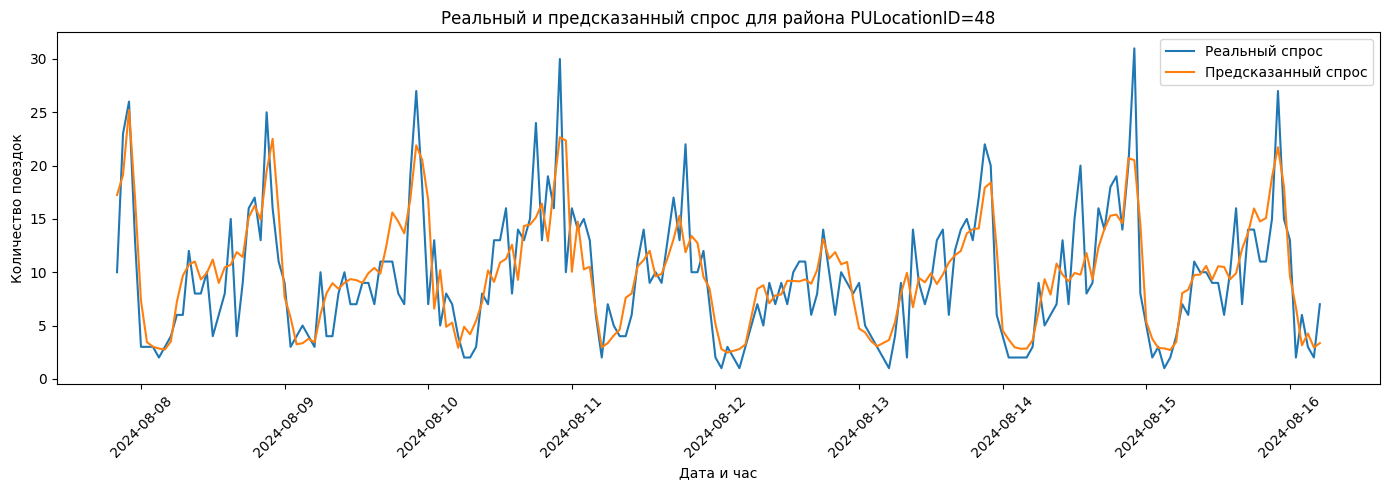

In [54]:
top_location = test_predictions["PULocationID"].value_counts().idxmax()

one_location = (
    test_predictions[test_predictions["PULocationID"] == top_location]
    .sort_values("date_hour")
    .head(200)
)

plt.figure(figsize=(14, 5))
plt.plot(one_location["date_hour"], one_location["demand"], label="Реальный спрос")
plt.plot(one_location["date_hour"], one_location["predicted_demand"], label="Предсказанный спрос")
plt.title(f"Реальный и предсказанный спрос для района PULocationID={top_location}")
plt.xlabel("Дата и час")
plt.ylabel("Количество поездок")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Прогноз для следующего часа

Для настоящего будущего прогноза нужна погода на будущий час.

В этом учебном варианте, если будущей погоды нет, мы используем последние известные погодные значения.

In [55]:
last_hour = hourly["date_hour"].max()
next_hour = last_hour + pd.Timedelta(hours=1)

print("Последний час в данных:", last_hour)
print("Прогнозируем следующий час:", next_hour)

latest_by_location = (
    hourly
    .sort_values(["PULocationID", "date_hour"])
    .groupby("PULocationID")
    .tail(1)
    .copy()
)

future = latest_by_location.copy()
future["date_hour"] = next_hour

future["month"] = future["date_hour"].dt.month
future["day"] = future["date_hour"].dt.day
future["hour"] = future["date_hour"].dt.hour
future["dayofweek"] = future["date_hour"].dt.dayofweek
future["is_weekend"] = (future["dayofweek"] >= 5).astype(int)

future["lag_1_demand"] = future["demand"]
future["lag_1_revenue"] = future["revenue"]

X_future = future[features].copy()

future["predicted_demand"] = np.maximum(demand_model.predict(X_future), 0)
future["predicted_revenue"] = np.maximum(revenue_model.predict(X_future), 0)

next_hour_predictions = future[
    ["date_hour", "PULocationID", "predicted_demand", "predicted_revenue"]
].copy()

next_hour_predictions = next_hour_predictions.sort_values(
    "predicted_revenue",
    ascending=False
)

display(next_hour_predictions.head(20))

next_hour_predictions.to_csv(
    TABLES_DIR / "next_hour_predictions_with_weather.csv",
    index=False
)

next_hour_predictions.head(20).to_csv(
    TABLES_DIR / "top20_next_hour_by_revenue_with_weather.csv",
    index=False
)

next_hour_predictions.sort_values(
    "predicted_demand",
    ascending=False
).head(20).to_csv(
    TABLES_DIR / "top20_next_hour_by_demand_with_weather.csv",
    index=False
)

print("Прогнозы сохранены в:", TABLES_DIR)

Последний час в данных: 2024-12-31 23:00:00
Прогнозируем следующий час: 2025-01-01 00:00:00


,date_hour,PULocationID,predicted_demand,predicted_revenue
950625,2025-01-01,132,23.174774,1649.117803
950627,2025-01-01,138,9.128671,581.188114
950608,2025-01-01,48,12.616019,341.001936
950649,2025-01-01,234,8.582551,279.117746
950635,2025-01-01,161,7.563900,271.975195
950629,2025-01-01,142,9.467932,261.450824
950614,2025-01-01,79,9.932584,251.129597
950611,2025-01-01,68,8.661627,247.973621
950642,2025-01-01,186,6.853465,247.823732
950638,2025-01-01,164,7.403591,238.491718


Прогнозы сохранены в: c:\Users\anast\Desktop\nyc_taxi_project\reports\tables


## 17. Итоговые файлы

После запуска появятся:

```text
models/demand_model_with_weather.joblib
models/revenue_model_with_weather.joblib
models/model_features_with_weather.joblib
```

И таблицы:

```text
reports/tables/train_hourly_with_weather.parquet
reports/tables/test_hourly_with_weather.parquet
reports/tables/model_metrics_with_weather.csv
reports/tables/test_predictions_with_weather.csv
reports/tables/next_hour_predictions_with_weather.csv
reports/tables/top20_next_hour_by_revenue_with_weather.csv
reports/tables/top20_next_hour_by_demand_with_weather.csv
```